In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import Bio
import Bio.Seq

## Import Dataset

In [2]:
df = pd.read_pickle("data/beta_activity.pkl")
df.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,11180,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10159,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3976,3


In [3]:
df.response.value_counts()

0    694
1    192
2     54
3     20
Name: response, dtype: int64

In [4]:
# number of sequences
Nseq = len(df)
Nseq

960

In [5]:
# WildType Sequence
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
WT = Bio.Seq.Seq(WT_DNA).translate()
WT

Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*', HasStopCodon(ExtendedIUPACProtein(), '*'))

In [6]:
# Length of a sequence
N = len(df.iloc[0].sequence)
N

274

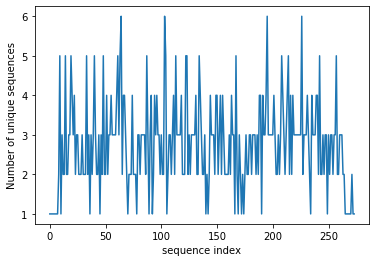

In [7]:
# Number of unique mutations at each index
num_unique = np.array([len(df.sequence.str.get(i).unique()) for i in range(N)])
plt.plot(num_unique)
plt.xlabel("sequence index")
plt.ylabel("Number of unique sequences");

In [8]:
len(df.sequence.unique())

900

In [9]:
len(df)

960

In [10]:
# location of the first stop sequence
df["first_stop"] = df.sequence.str.find("*")
print((df.first_stop != (N-1)).sum())
# print out wherever we have a stop in the middle
df[df.first_stop != (N-1)]

43


,sequence,count,response,first_stop
15,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1631,3,122
18,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1263,3,122
11,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,101,0,84
26,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,38,0,214
30,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,36,0,84
40,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,32,0,195
92,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,22,0,91
101,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,21,0,212
133,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17,0,167
146,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16,0,170


In [11]:
df[df.sequence == WT]

,sequence,count,response,first_stop
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1124,1,273
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,781,0,273


In [12]:
df_nostop = df[df.first_stop == (len(WT) -1)].drop(columns=['first_stop'])
df_nostop.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,11180,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10159,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3976,3


In [13]:
# Replace non-unique sequences with their response category with the highest count
df_unique = df_nostop.sort_values('count', ascending=False).groupby('sequence').head(1).reset_index(drop=True)
df_unique.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,20885,2
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10801,2
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,6016,2


In [14]:
df_unique[["sequence", "response"]].groupby("response").count()

,sequence
response,
0,615
1,178
2,53
3,11


In [15]:
# Where is WT in this dataframe
# It should be at the top
df_unique[df_unique.sequence==WT]

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2


In [16]:
# drop the start and stop codons
df_unique.sequence = df_unique.sequence.str.slice(1, (len(WT)-1))

## Ordinal regression

In [17]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
import mord
from mord import LogisticAT

In [18]:
design_cols = df_unique.sequence.apply(lambda x: pd.Series(list(x)))

# one hot encode the design columns to get a design matrix
enc = OneHotEncoder(
    drop=None, # don't drop columns 
    sparse=False ) # setting to False for now
X = enc.fit_transform(design_cols)
print(X.shape)
X

(857, 723)


array([[1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       ...,
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.]])

In [19]:
enc.get_feature_names().size

723

In [20]:
y = df_unique.response.to_numpy()

In [21]:
# Try out model with alpha = 1.0
model = mord.LogisticAT(alpha=1.0)
model._estimator_type = "classifier" # for CV to use Stratified Kfold
model.fit(X, y)
model.score(X, y)

-0.13885647607934656

In [22]:
#model = Ridge(alpha=1.0)
#model.fit(X,y)
#model.score(X, y)

In [23]:
from sklearn.model_selection import GridSearchCV, cross_val_score

In [24]:
alphas = np.logspace(-6, 2, 10) # search space for regularization params
grid_cv = GridSearchCV(estimator=model, param_grid=dict(alpha=alphas), cv=5, iid='deprecated')
grid_cv.fit(X, y)

GridSearchCV(cv=5, error_score='raise-deprecating',
             estimator=LogisticAT(alpha=1.0, max_iter=1000, verbose=0),
             iid='deprecated', n_jobs=None,
             param_grid={'alpha': array([1.00000000e-06, 7.74263683e-06, 5.99484250e-05, 4.64158883e-04,
       3.59381366e-03, 2.78255940e-02, 2.15443469e-01, 1.66810054e+00,
       1.29154967e+01, 1.00000000e+02])},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=0)

In [25]:
grid_cv.cv_results_

{'mean_fit_time': array([1.30969787, 1.3068387 , 1.3051168 , 1.29957466, 1.28982005,
        1.29720979, 1.24593172, 0.64923611, 0.26442609, 0.13753829]),
 'std_fit_time': array([0.00938992, 0.03726376, 0.01734343, 0.01633831, 0.01210192,
        0.01271162, 0.0648423 , 0.03820311, 0.02704291, 0.02440607]),
 'mean_score_time': array([0.00045857, 0.00081868, 0.00056205, 0.000634  , 0.00040359,
        0.00039868, 0.00044308, 0.00047178, 0.00040002, 0.00040359]),
 'std_score_time': array([6.55290504e-05, 5.91828613e-04, 1.61017932e-04, 2.88909114e-04,
        1.12319193e-05, 4.58954217e-06, 8.79044613e-05, 1.39160037e-04,
        4.34262278e-06, 1.09261281e-05]),
 'param_alpha': masked_array(data=[1e-06, 7.742636826811277e-06, 5.994842503189409e-05,
                    0.00046415888336127773, 0.003593813663804626,
                    0.02782559402207126, 0.21544346900318823,
                    1.6681005372000557, 12.915496650148826, 100.0],
              mask=[False, False, False, False

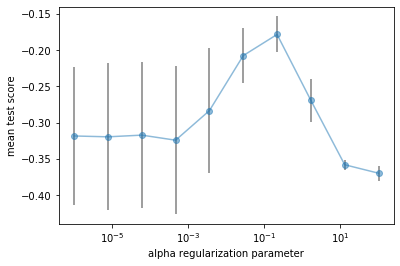

In [26]:
plt.errorbar(alphas, grid_cv.cv_results_["mean_test_score"],
             grid_cv.cv_results_["std_test_score"], fmt='-o', ecolor="black", alpha=0.5)
plt.xscale('log')
plt.xlabel("alpha regularization parameter")
plt.ylabel("mean test score");

In [27]:
# regularization parameter picked by CV
grid_cv.best_params_

{'alpha': 0.21544346900318823}

In [28]:
grid_cv.best_score_

-0.17852975495915985

In [29]:
from sklearn.metrics import classification_report

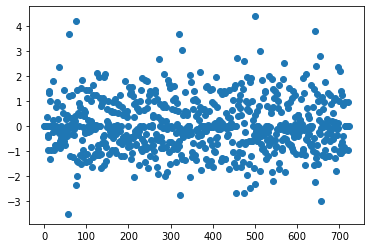

In [30]:
best_coefs = grid_cv.best_estimator_.coef_
plt.plot(best_coefs, 'o')

In [31]:
best_results = pd.DataFrame({'feature':enc.get_feature_names(), 'coef':best_coefs})

In [32]:
best_results.sort_values('coef', ascending=False).head(10)

,feature,coef
500,x190_S,4.378919
76,x32_K,4.194147
642,x237_Q,3.801739
321,x121_I,3.683613
58,x24_T,3.650771
327,x122_S,3.022536
512,x194_L,2.974603
654,x241_K,2.802715
457,x174_R,2.691064
272,x103_G,2.665057


In [33]:
def show_design_response(col_num):
    return pd.DataFrame({'aa':design_cols[col_num], 'response':y}).groupby(['aa', 'response']).size()
show_design_response(33)

aa  response
A   0           614
    1           178
    2            53
    3            11
P   0             1
dtype: int64

In [34]:
show_design_response(191)

aa  response
I   1             1
K   0             2
M   0           613
    1           177
    2            53
    3            11
dtype: int64

In [35]:
best_results.sort_values('coef', ascending=True).head(10)

,feature,coef
56,x24_A,-3.519012
656,x241_R,-3.015384
323,x121_R,-2.763910
474,x181_S,-2.699729
456,x174_H,-2.690687
489,x187_I,-2.471333
75,x32_G,-2.361393
499,x190_R,-2.321853
643,x237_V,-2.247858
544,x204_P,-2.186358


In [36]:
show_design_response(238)

aa  response
F   0           596
    1           178
    2            53
    3            11
L   0            10
S   0             9
dtype: int64

In [37]:
show_design_response(214)

aa  response
A   0             2
    1             1
T   0           613
    1           177
    2            53
    3            11
dtype: int64

In [38]:
pd.set_option('display.max_rows', 1000)
best_results

,feature,coef
0,x0_Q,0.000377
1,x1_H,0.000377
2,x2_T,0.000377
3,x3_Y,0.000377
4,x4_P,0.000377
5,x5_A,0.000377
6,x6_Q,0.000377
7,x7_L,0.352589
8,x7_P,-0.352212
9,x8_I,-0.958023
